# 14: The Digital Crystal

Digital Crystal v1: a fixed local stochastic growth process. Quick cells recompute the mechanism; canonical chapter values are audited from committed research artifacts.


In [1]:
from pathlib import Path
import json
import math
import random
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams, CrystalState, neighbors, hex_distance, hex_capacity,
    axial_to_xy, logistic, local_exposure_angle, initial_state, clone_state,
    morphology_hash, frontier, attachment_probability, advance_one_step,
    run_crystal, cell_keyed_uniform,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

NOTEBOOK_PROFILE = "quick"
RUN_CANONICAL = False

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def audit(expected, observed, source):
    return {
        "source": source,
        "expected": expected,
        "observed": observed,
        "matches": {k: observed.get(k) == v for k, v in expected.items()},
    }

def plot_cells(cells, title, ax=None, color="tab:blue"):
    ax = ax or plt.gca()
    pts = np.array([axial_to_xy(c) for c in cells]) if cells else np.empty((0, 2))
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], marker="h", s=42, c=color, alpha=0.9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


In [2]:
def make_signal(kind, steps, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(steps)
    if kind == "constant":
        return np.full(steps, 0.5)
    if kind == "sine":
        return 0.5 + 0.45 * np.sin(2 * np.pi * t / max(8, steps // 2))
    if kind == "square":
        return ((t // max(2, steps // 6)) % 2).astype(float)
    if kind == "saw":
        return (t % max(3, steps // 4)) / max(3, steps // 4)
    if kind == "white_noise":
        return rng.random(steps)
    if kind == "random_walk":
        x = np.cumsum(rng.normal(0, 0.08, steps)) + 0.5
        return np.clip(x, 0, 1)
    raise ValueError(kind)

def morphology_features(cells):
    area = len(cells)
    boundary = sum(1 for c in cells if any(nb not in cells for nb in neighbors(c)))
    max_r = max(hex_distance(c) for c in cells)
    pts = np.array([axial_to_xy(c) for c in cells])
    centroid = pts.mean(axis=0)
    radii = np.linalg.norm(pts - centroid, axis=1)
    return {
        "area": area,
        "boundary_edges": boundary,
        "max_radius": max_r,
        "radial_mean": float(radii.mean()),
        "radial_std": float(radii.std()),
    }


In [3]:
PARAMS = CrystalParams()
EXPERIMENT = {
    "steps": 36,
    "max_radius": 24,
    "signal_families": ["constant", "sine", "square", "saw", "white_noise", "random_walk"],
    "params": PARAMS.__dict__,
}
EXPERIMENT


{'steps': 36,
 'max_radius': 24,
 'signal_families': ['constant',
  'sine',
  'square',
  'saw',
  'white_noise',
  'random_walk'],
 'params': {'base_bias': -2.1,
  'neighbor_gain': 0.78,
  'signal_rate_gain': 0.28,
  'anisotropy_gain': 0.95,
  'signal_phase_gain': 1.15,
  'crowding_penalty': 0.22}}

## Frozen attachment mechanism

The central relationship stays visible in the notebook.


In [4]:
cell = (1, 0)
occupied = {(0, 0)}
input_value = 0.75
n = sum(nb in occupied for nb in neighbors(cell))
theta = local_exposure_angle(cell, occupied)
anisotropy = math.cos(6.0 * theta + PARAMS.signal_phase_gain * input_value)
crowding = max(0, n - 2)
score = (
    PARAMS.base_bias
    + PARAMS.neighbor_gain * n
    + PARAMS.signal_rate_gain * input_value
    + PARAMS.anisotropy_gain * anisotropy
    - PARAMS.crowding_penalty * crowding
)
{"score": score, "P_attach": logistic(score), "neighbors": n, "anisotropy": anisotropy, "crowding": crowding}


{'score': -0.4919862163788816,
 'P_attach': 0.3794257775845383,
 'neighbors': 1,
 'anisotropy': 0.6505408248643353,
 'crowding': 0}

## Shared helper regression check

This checks that the helper's probability agrees with the explicit frozen formula above.


In [5]:
helper_p = attachment_probability(cell, occupied, input_value, PARAMS)
assert abs(helper_p - logistic(score)) < 1e-12
{"explicit": logistic(score), "shared_helper": helper_p, "match": True}


{'explicit': 0.3794257775845383,
 'shared_helper': 0.3794257775845383,
 'match': True}

## Same mechanism, different forcing families


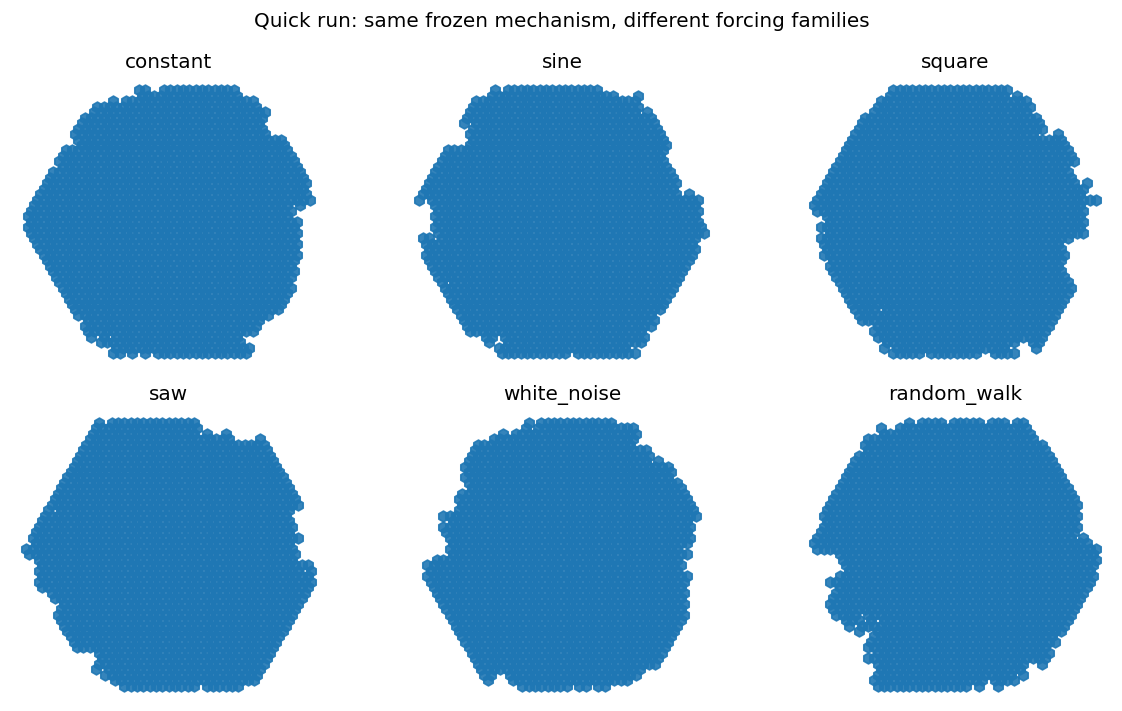

{'constant': {'area': 1681,
  'boundary_edges': 171,
  'max_radius': 24,
  'radial_mean': 24.927581102169697,
  'radial_std': 8.887546700026748},
 'sine': {'area': 1698,
  'boundary_edges': 178,
  'max_radius': 24,
  'radial_mean': 25.066556935640254,
  'radial_std': 8.948547303219422},
 'square': {'area': 1665,
  'boundary_edges': 178,
  'max_radius': 24,
  'radial_mean': 24.829503855651037,
  'radial_std': 8.869467502702374},
 'saw': {'area': 1691,
  'boundary_edges': 167,
  'max_radius': 24,
  'radial_mean': 25.018149063827554,
  'radial_std': 8.936176980957722},
 'white_noise': {'area': 1626,
  'boundary_edges': 167,
  'max_radius': 24,
  'radial_mean': 24.543479916988723,
  'radial_std': 8.77258502194338},
 'random_walk': {'area': 1669,
  'boundary_edges': 185,
  'max_radius': 24,
  'radial_mean': 24.884232177659186,
  'radial_std': 8.91025735014068}}

In [6]:
states = {}
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, kind in zip(axes.flat, EXPERIMENT["signal_families"]):
    signal = make_signal(kind, EXPERIMENT["steps"], seed=11)
    state = run_crystal(signal, seed=101, max_radius=EXPERIMENT["max_radius"], params=PARAMS)
    states[kind] = state
    plot_cells(state.occupied, kind, ax=ax)
fig.suptitle("Quick run: same frozen mechanism, different forcing families")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch14-forcing-families-quick.png", bbox_inches="tight")
plt.show()
{k: morphology_features(v.occupied) for k, v in states.items()}


## Exact-same-multiset temporal control


In [7]:
base = make_signal("random_walk", 40, seed=42)
ordered = base.copy()
shuffled = base.copy()
np.random.default_rng(5).shuffle(shuffled)
assert sorted(ordered.tolist()) == sorted(shuffled.tolist())
same_multiset = {
    "same_values": bool(np.allclose(np.sort(ordered), np.sort(shuffled))),
    "same_order": bool(np.allclose(ordered, shuffled)),
    "ordered_first_8": np.round(ordered[:8], 3).tolist(),
    "shuffled_first_8": np.round(shuffled[:8], 3).tolist(),
}
same_multiset


{'same_values': True,
 'same_order': False,
 'ordered_first_8': [0.524, 0.441, 0.501, 0.576, 0.42, 0.316, 0.326, 0.301],
 'shuffled_first_8': [0.712, 0.451, 0.326, 0.429, 0.401, 0.57, 0.232, 0.463]}

## Canonical artifact audit


In [8]:
baseline = load_json("research/digital-life/ch14-reports/stage-01-baseline.json")
summary = load_json("research/digital-life/ch14-reports/ch14-summary.json")
robustness = load_json("research/digital-life/ch14-reports/stage-08-robustness.json")
observed = {
    "baseline_population": baseline["final_population"],
    "baseline_max_radius": baseline["max_radius"],
    "baseline_boundary_edges": baseline["final_perimeter"],
    "source_rf": round(summary["source_recovery"]["random_forest_accuracy"], 3),
    "source_logistic": round(summary["source_recovery"]["logistic_accuracy"], 3),
    "temporal_rf": round(summary["temporal_order_recovery"]["random_forest_accuracy"], 3),
    "temporal_logistic": round(summary["temporal_order_recovery"]["logistic_accuracy"], 3),
}
EXPECTED = {
    "baseline_population": 5924,
    "baseline_max_radius": 44,
    "baseline_boundary_edges": 552,
    "source_rf": 0.522,
    "source_logistic": 0.539,
    "temporal_rf": 0.513,
    "temporal_logistic": 0.517,
}
audit(EXPECTED, observed, "canonical report artifact")


{'source': 'canonical report artifact',
 'expected': {'baseline_population': 5924,
  'baseline_max_radius': 44,
  'baseline_boundary_edges': 552,
  'source_rf': 0.522,
  'source_logistic': 0.539,
  'temporal_rf': 0.513,
  'temporal_logistic': 0.517},
 'observed': {'baseline_population': 5924,
  'baseline_max_radius': 44,
  'baseline_boundary_edges': 552,
  'source_rf': 0.522,
  'source_logistic': 0.539,
  'temporal_rf': 0.513,
  'temporal_logistic': 0.517},
 'matches': {'baseline_population': True,
  'baseline_max_radius': True,
  'baseline_boundary_edges': True,
  'source_rf': True,
  'source_logistic': True,
  'temporal_rf': True,
  'temporal_logistic': True}}

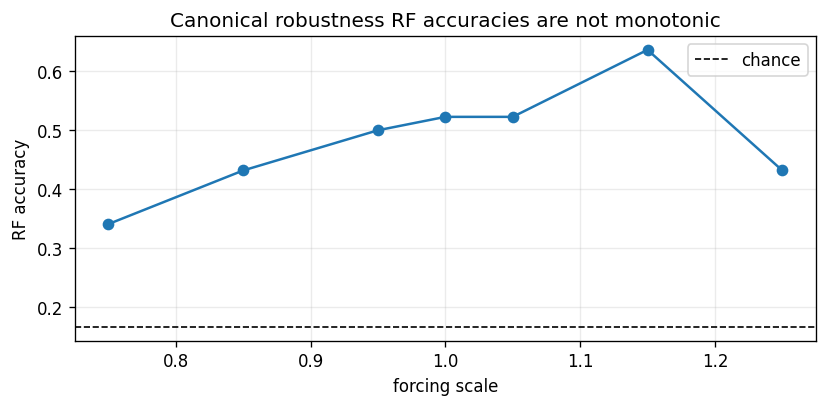

[(0.75, 0.3409090909090909),
 (0.85, 0.4318181818181818),
 (0.95, 0.5),
 (1.0, 0.5227272727272727),
 (1.05, 0.5227272727272727),
 (1.15, 0.6363636363636364),
 (1.25, 0.4318181818181818)]

In [9]:
levels = sorted((float(k), v["random_forest_accuracy"]) for k, v in robustness.items())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot([x for x, _ in levels], [y for _, y in levels], marker="o")
ax.axhline(1/6, color="k", ls="--", lw=1, label="chance")
ax.set(title="Canonical robustness RF accuracies are not monotonic", xlabel="forcing scale", ylabel="RF accuracy")
ax.legend(); ax.grid(alpha=0.25); fig.tight_layout()
fig.savefig(FIG_DIR / "ch14-robustness-artifact-audit.png", bbox_inches="tight")
plt.show()
levels


## Bounded conclusion

Canonical artifacts support source-family recovery above chance and do not support exact temporal-order recovery from final morphology. This is morphology-carried source-family information, not memory.

## Provenance

Book chapter: `content/books/digital-life/14-the-digital-crystal/index.md`

Research scripts: `ch14_digital_crystal.py`, `ch14_digital_crystal_temporal_matched.py`

Canonical research artifacts: `research/digital-life/ch14-reports/`

Book figures associated: `ch14-01-baseline.png`, `ch14-02-source-signals.png`, `ch14-06-source-accuracy.png`, `ch14-07-order-accuracy.png`, `ch14-08-robustness.png`

Notebook-generated figures: `ch14-forcing-families-quick.png`, `ch14-robustness-artifact-audit.png`

Execution mode: quick-recomputed + canonical-artifact-audit
